выгрузка данных


In [ ]:
!pip install aiomoex aiohttp pandas tqdm

import asyncio
import aiohttp
import aiomoex
import pandas as pd
from tqdm import tqdm

# Список тикеров (33 акции)
tickers = [
    'SBER', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'GMKN', 'SIBN',
    'PLZL', 'PHOR', 'VTBR', 'TATN', 'MOEX', 'MTSS', 'NLMK',
    'MAGN', 'SNGS', 'SNGSP', 'AFKS', 'RUAL', 'AFLT',
    'TRNFP', 'HYDR', 'LSRG', 'MRKC', 'MRKP',
    'CBOM', 'ALRS', 'IRAO', 'CHMF',
    'FEES', 'UPRO', 'BSPB', 'PIKK'
]

print(f"Загружаем данные по {len(tickers)} акциям за период 2019-2025")

async def fetch_ticker_data(session, ticker):
    """Загружает данные по тикеру"""
    try:
        data = await aiomoex.get_board_history(
            session,
            ticker,
            start='2019-01-01',
            end='2025-12-31',
            columns=['TRADEDATE', 'CLOSE']
        )

        if data and len(data) > 0:
            df = pd.DataFrame(data)
            df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
            df = df.set_index('TRADEDATE').sort_index()
            # Возвращаем Series с именем равным тикеру
            return ticker, pd.Series(df['CLOSE'].values, index=df.index, name=ticker)
        else:
            print(f"✗ {ticker}: нет данных")
            return ticker, None

    except Exception as e:
        print(f"✗ {ticker}: ошибка - {e}")
        return ticker, None

async def main():
    async with aiohttp.ClientSession() as session:
        tasks = [fetch_ticker_data(session, ticker) for ticker in tickers]
        results = []

        for future in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Загрузка"):
            ticker, series = await future
            if series is not None:
                results.append(series)

        if results:
            # Объединяем все данные
            price_matrix = pd.concat(results, axis=1)

            print("\n" + "="*60)
            print("РЕЗУЛЬТАТЫ ЗАГРУЗКИ:")
            print("="*60)
            print(f"Размер матрицы: {price_matrix.shape[0]} дней × {price_matrix.shape[1]} акций")
            print(f"Период: с {price_matrix.index.min().date()} по {price_matrix.index.max().date()}")
            print(f"\nКолонки матрицы: {list(price_matrix.columns)}")

            # Сохраняем
            price_matrix.to_csv("moex_prices_2019_2025.csv")

            # Создаем фильтрованную версию (убираем дни, где более 10% пропусков)
            threshold = int(0.9 * price_matrix.shape[1])
            filtered_matrix = price_matrix.dropna(thresh=threshold)
            filtered_matrix.to_csv("moex_prices_filtered.csv")

            print(f"\n✅ Данные сохранены:")
            print(f"   - Полная матрица: {price_matrix.shape}")
            print(f"   - Фильтрованная: {filtered_matrix.shape}")

            return price_matrix, filtered_matrix
        else:
            print("❌ Не удалось загрузить данные")
            return None, None

# Запускаем
price_matrix, filtered_matrix = await main()

print("\n" + "="*60)
print("ПОСЛЕДНИЕ 5 ТОРГОВЫХ ДНЕЙ (с тикерами):")
print("="*60)
print(price_matrix.tail(5))

print("\n" + "="*60)
print("ПЕРВЫЕ 5 ТОРГОВЫХ ДНЕЙ (с тикерами):")
print("="*60)
print(price_matrix.head(5))

print("\n" + "="*60)
print("СПИСОК ЗАГРУЖЕННЫХ АКЦИЙ:")
print("="*60)
for i, col in enumerate(price_matrix.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n✅ Загрузка завершена. Всего загружено {price_matrix.shape[1]} акций.")

Загружаем данные по 33 акциям за период 2019-2025


Загрузка: 100%|██████████| 33/33 [00:05<00:00,  6.21it/s]



РЕЗУЛЬТАТЫ ЗАГРУЗКИ:
Размер матрицы: 1773 дней × 33 акций
Период: с 2019-01-03 по 2025-12-30

Колонки матрицы: ['SNGS', 'GAZP', 'ALRS', 'VTBR', 'MTSS', 'LSRG', 'CHMF', 'TRNFP', 'ROSN', 'PIKK', 'TATN', 'FEES', 'MAGN', 'IRAO', 'PLZL', 'NLMK', 'UPRO', 'HYDR', 'BSPB', 'MRKC', 'SIBN', 'MOEX', 'LKOH', 'CBOM', 'MRKP', 'SNGSP', 'GMKN', 'PHOR', 'AFLT', 'RUAL', 'AFKS', 'NVTK', 'SBER']

✅ Данные сохранены:
   - Полная матрица: (1773, 33)
   - Фильтрованная: (1753, 33)

ПОСЛЕДНИЕ 5 ТОРГОВЫХ ДНЕЙ (с тикерами):
              SNGS    GAZP   ALRS   VTBR    MTSS   LSRG   CHMF   TRNFP  \
TRADEDATE                                                                
2025-12-24  22.135  125.04  42.36  71.60  211.75  658.6  965.8  1353.8   
2025-12-25  21.920  124.20  42.34  71.40  210.55  640.2  964.2  1349.6   
2025-12-26  22.150  127.37  43.00  72.92  212.25  650.2  980.0  1390.8   
2025-12-29  21.665  125.29  41.56  72.17  212.35  649.0  967.6  1377.4   
2025-12-30  21.715  125.36  41.38  72.22  213.90  64

лог доходности


In [ ]:
import numpy as np

returns = np.log(price_matrix / price_matrix.shift(1))
returns = returns.dropna()

print("Размер матрицы доходностей:", returns.shape)
returns.head()

Размер матрицы доходностей: (1710, 33)


,SNGS,GAZP,ALRS,VTBR,MTSS,LSRG,CHMF,TRNFP,ROSN,PIKK,...,CBOM,MRKP,SNGSP,GMKN,PHOR,AFLT,RUAL,AFKS,NVTK,SBER
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2019-01-04,0.009660,0.018198,0.015481,0.011914,0.033125,0.012908,0.016456,0.024866,0.010628,0.001334,...,0.000580,-0.002247,-0.008980,0.005909,0.003547,-0.003949,0.008458,0.024198,0.018255,0.021166
2019-01-08,-0.001295,-0.005608,-0.028973,0.006335,0.005816,0.025967,0.003154,-0.018959,-0.015925,0.003724,...,0.000193,0.008215,-0.003615,0.004428,-0.011076,0.000000,-0.033768,-0.007064,-0.018255,0.001308
2019-01-09,0.002219,0.012433,0.027495,0.004582,0.007768,0.007660,0.020673,-0.011551,0.009632,-0.005058,...,-0.004261,-0.003726,-0.007008,0.007664,0.002781,0.009451,-0.015193,0.014439,0.002501,0.029675
2019-01-10,0.013393,-0.000250,0.015170,0.001285,0.015748,0.011067,-0.002677,0.008011,0.010235,-0.001335,...,0.002133,0.000746,0.015765,0.008581,-0.002781,0.029732,0.023534,0.003007,0.010206,-0.001270
2019-01-11,0.007083,0.004981,0.010147,0.003987,-0.012579,-0.021937,0.002574,0.007654,0.005769,-0.014265,...,0.003673,0.007062,0.004350,0.007020,0.001987,-0.004576,0.038780,0.013836,-0.002741,0.000254


описательная статистика


In [ ]:
desc_stats = returns.describe().T
desc_stats['skew'] = returns.skew()
desc_stats['kurtosis'] = returns.kurtosis()

desc_stats.head()


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
SNGS,1710.0,0.000149,0.023278,-0.181360,-0.010835,-0.000446,0.009796,0.175365,0.388736,10.809529
GAZP,1710.0,0.000137,0.023519,-0.363200,-0.009566,-0.000321,0.009700,0.222751,-1.849408,44.076887
ALRS,1710.0,-0.000305,0.020202,-0.135854,-0.011165,-0.000153,0.010386,0.100348,-0.301513,4.020276
VTBR,1710.0,-0.000023,0.022827,-0.249955,-0.009758,-0.000422,0.008874,0.143392,-0.663075,17.283086
MTSS,1710.0,0.000216,0.018186,-0.165503,-0.006502,0.000517,0.007125,0.287968,1.164042,50.991315


In [ ]:
corr = returns.corr()

# Средняя корреляция (без диагонали)
mean_corr = corr.where(~np.eye(corr.shape[0], dtype=bool)).mean().mean()

# Максимальная и минимальная (без диагонали)
corr_values = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack()

print("Средняя корреляция:", mean_corr)
print("Максимальная корреляция:", corr_values.max())
print("Минимальная корреляция:", corr_values.min())

Средняя корреляция: 0.40863430770214054
Максимальная корреляция: 0.7686497512219046
Минимальная корреляция: 0.1525107119249407


ассиментрия и эксцессс

In [ ]:
print("Минимальная асимметрия:", returns.skew().min())
print("Максимальная асимметрия:", returns.skew().max())

print("Минимальный эксцесс:", returns.kurtosis().min())
print("Максимальный эксцесс:", returns.kurtosis().max())


Минимальная асимметрия: -2.6426246900483656
Максимальная асимметрия: 1.3799914274241818
Минимальный эксцесс: 4.020275884492774
Максимальный эксцесс: 50.991315227599415


In [ ]:
print("Минимальная волатильность:", returns.std().min())
print("Максимальная волатильность:", returns.std().max())
print("Средняя волатильность:", returns.std().mean())


Минимальная волатильность: 0.015843914610783376
Максимальная волатильность: 0.024599986258669736
Средняя волатильность: 0.020512532742259917


In [ ]:
print("Размер матрицы доходностей:", returns.shape)


Размер матрицы доходностей: (1710, 33)


Сравнительная дневная волатильность акций выборки рисунок


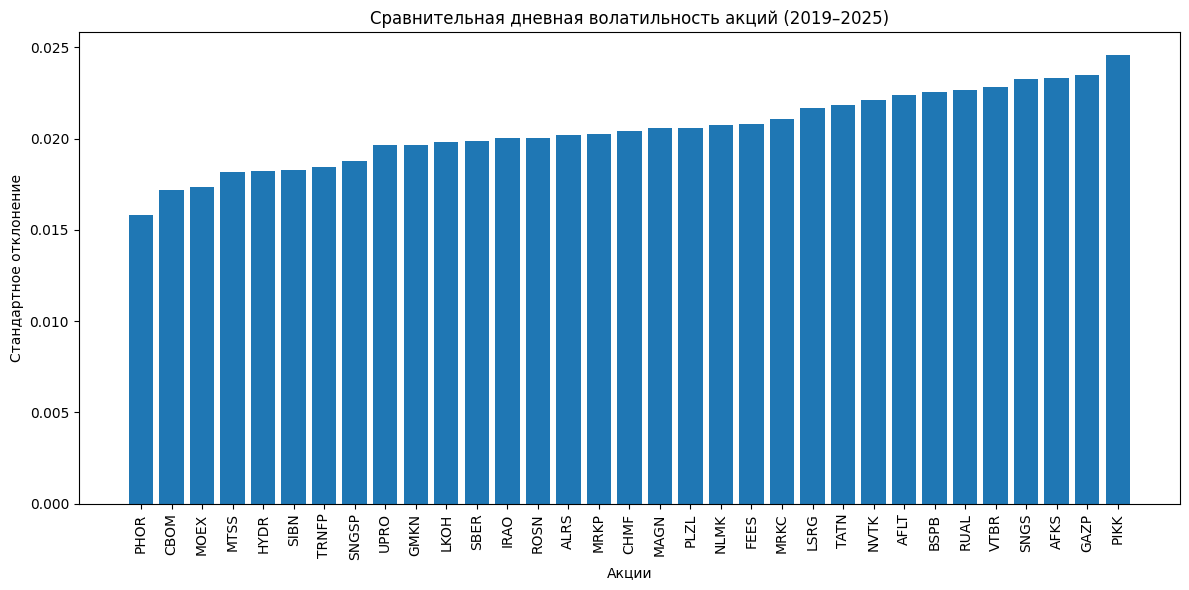

In [ ]:
import matplotlib.pyplot as plt

volatility = returns.std().sort_values()

plt.figure(figsize=(12,6))
plt.bar(volatility.index, volatility.values)
plt.xticks(rotation=90)
plt.title("Сравнительная дневная волатильность акций (2019–2025)")
plt.ylabel("Стандартное отклонение")
plt.xlabel("Акции")
plt.tight_layout()
plt.show()


Динамика средней рыночной доходности


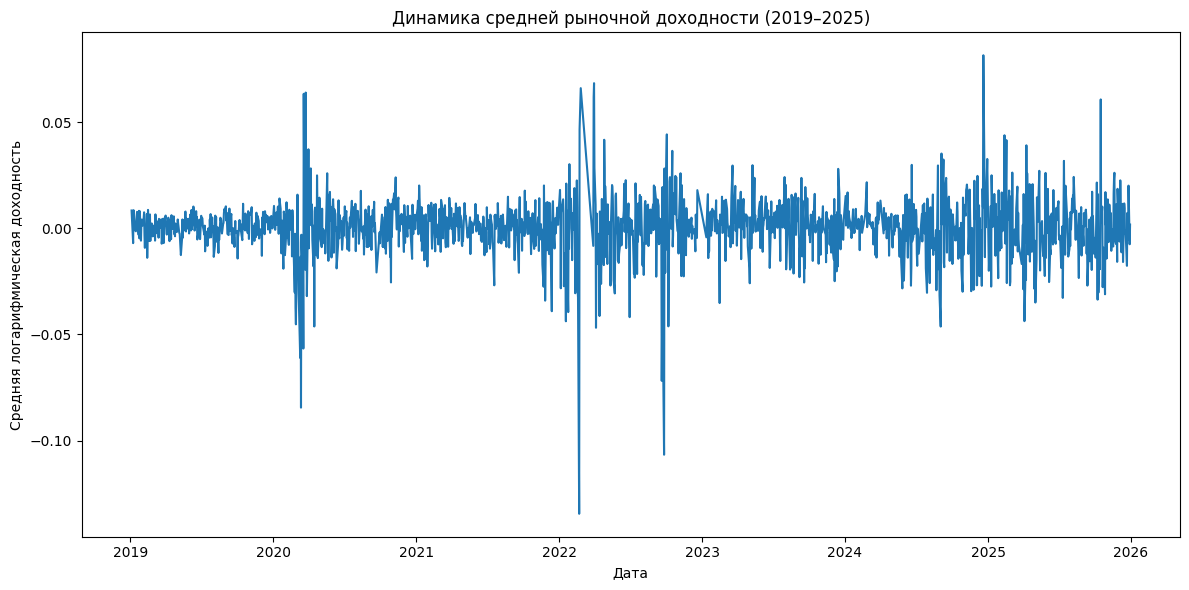

In [ ]:


returns.index = pd.to_datetime(returns.index)

mean_returns = returns.mean(axis=1, skipna=True)

plt.figure(figsize=(12,6))
plt.plot(mean_returns)
plt.title("Динамика средней рыночной доходности (2019–2025)")
plt.ylabel("Средняя логарифмическая доходность")
plt.xlabel("Дата")
plt.tight_layout()
plt.show()


Корреляционная матрица доходностей акций

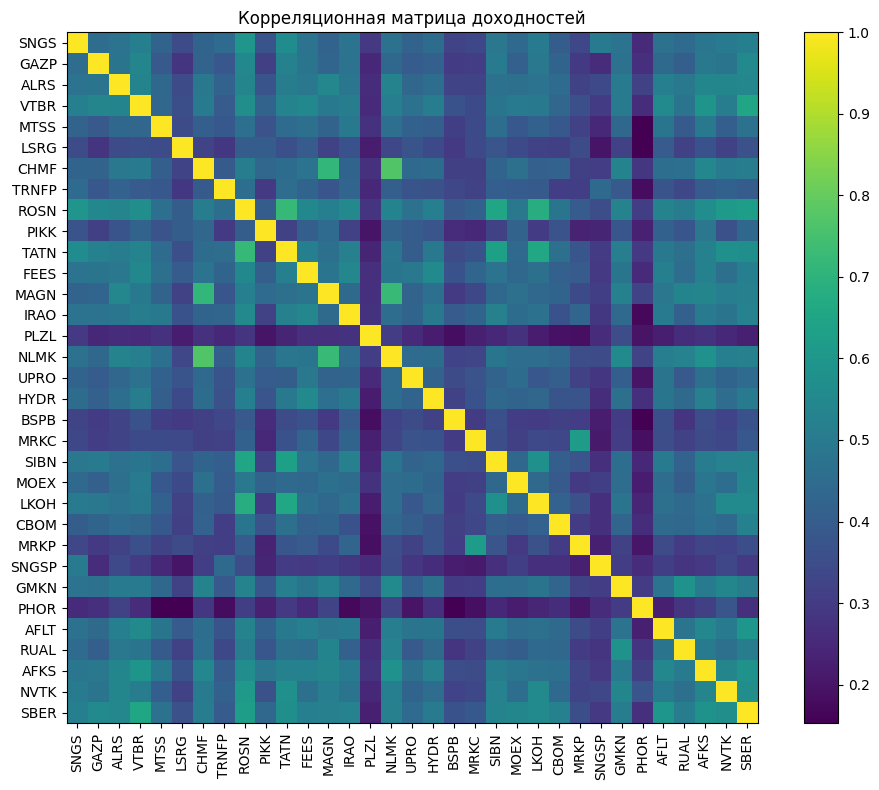

In [ ]:
corr = returns.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляционная матрица доходностей")
plt.tight_layout()
plt.show()


Распределение логарифмических доходностей акции

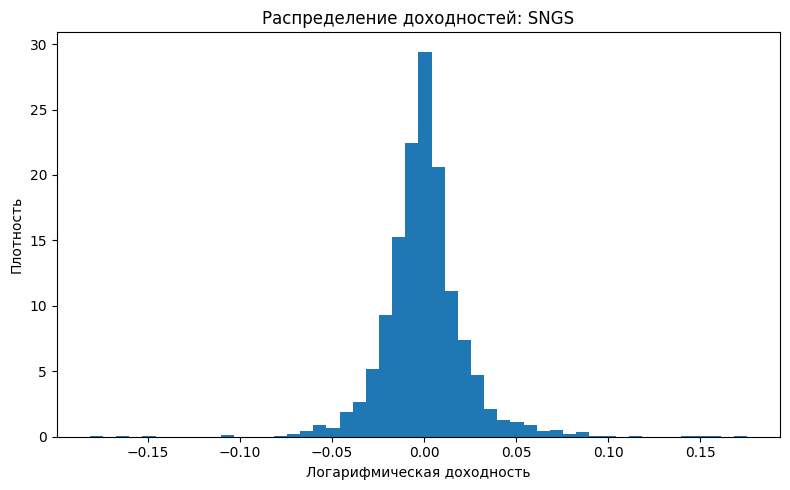

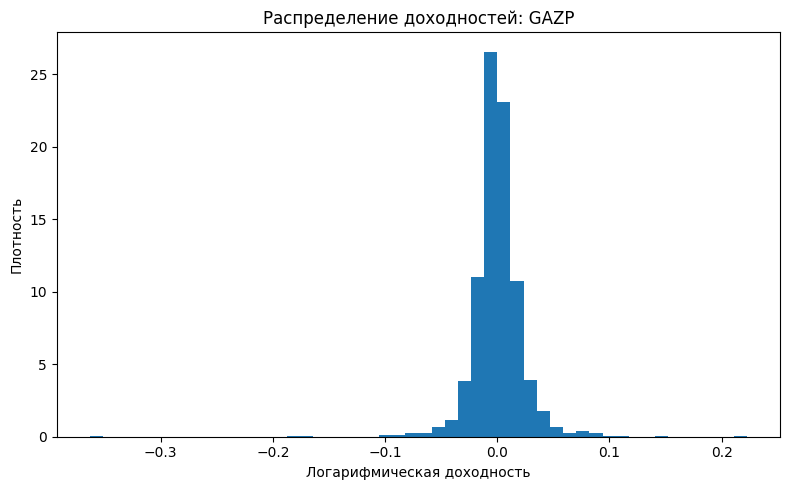

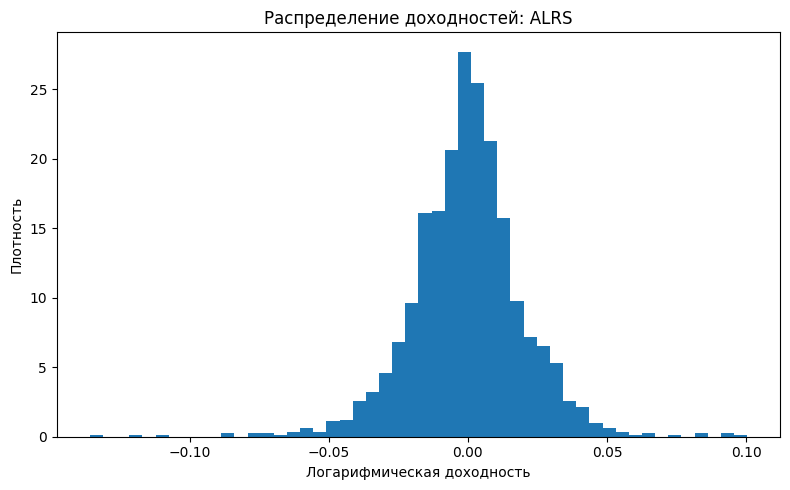

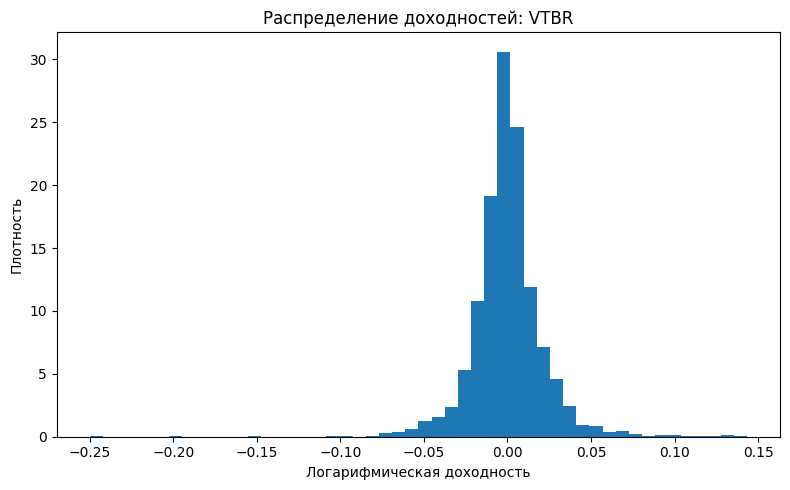

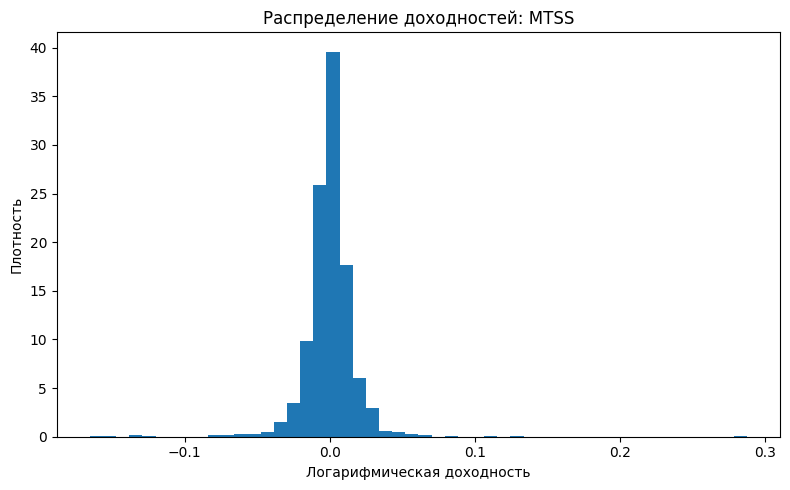

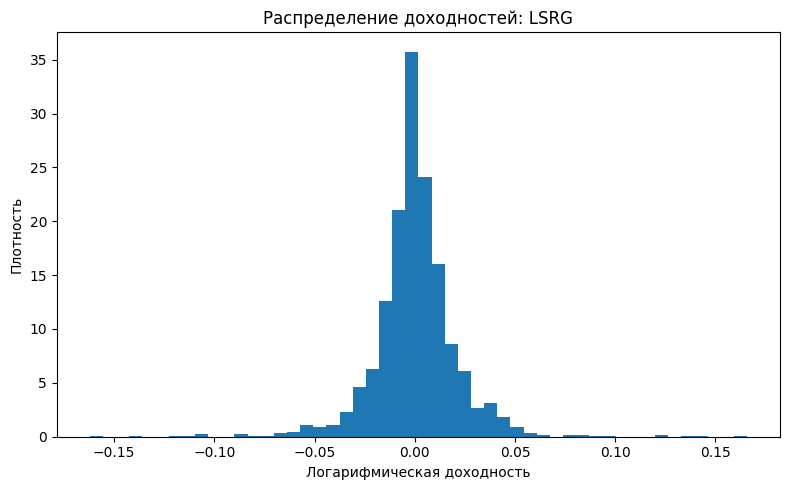

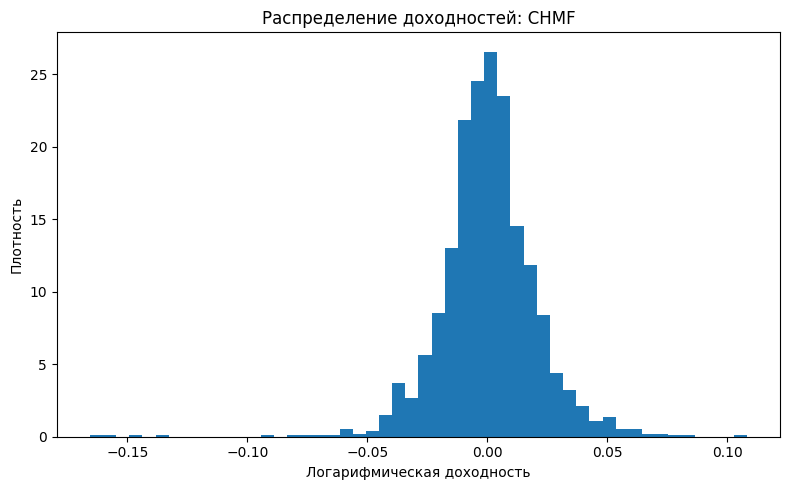

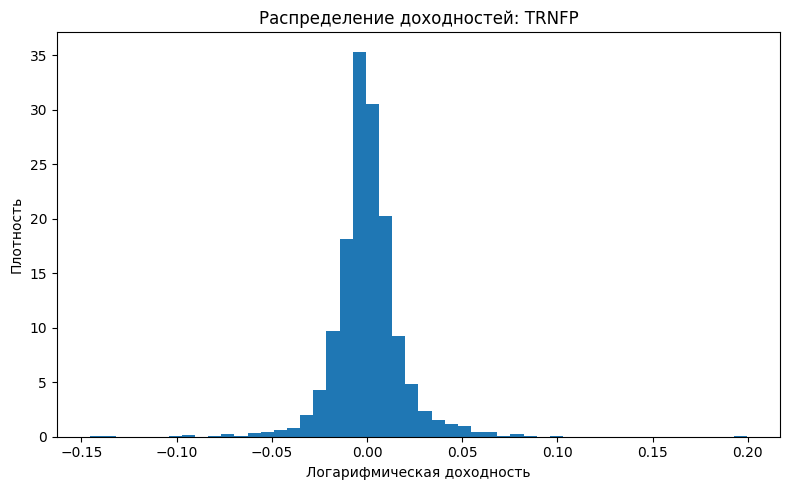

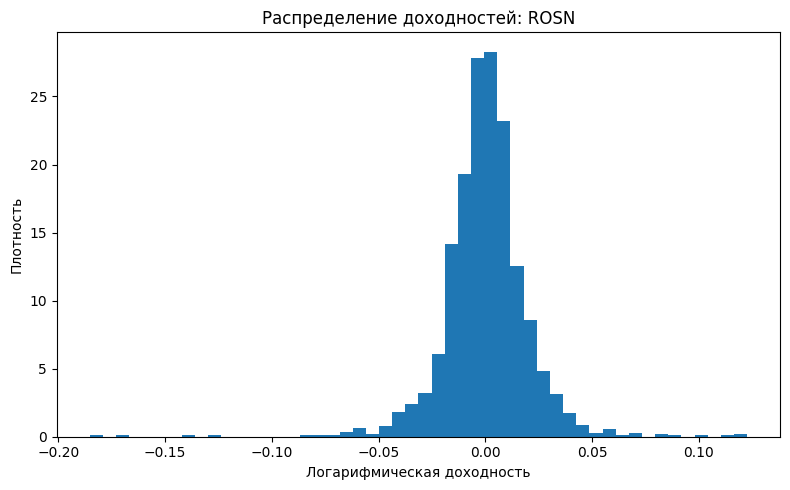

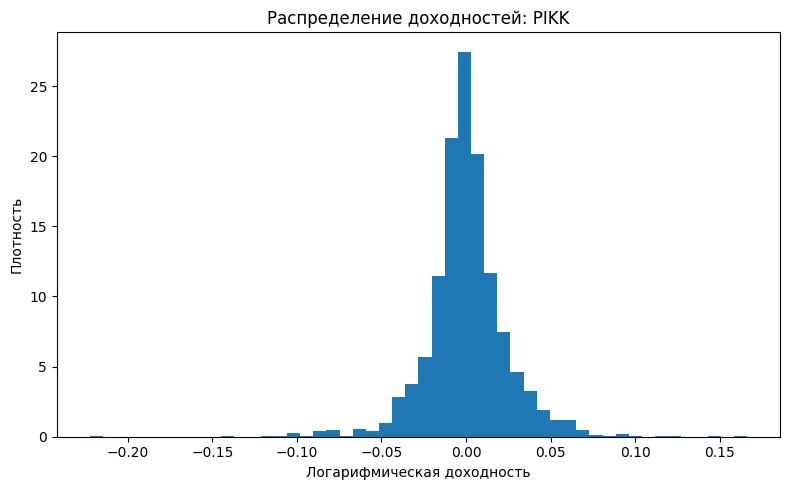

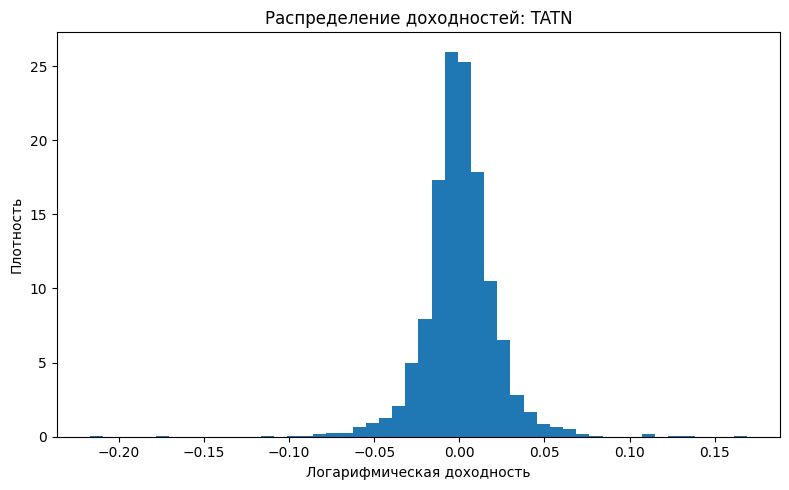

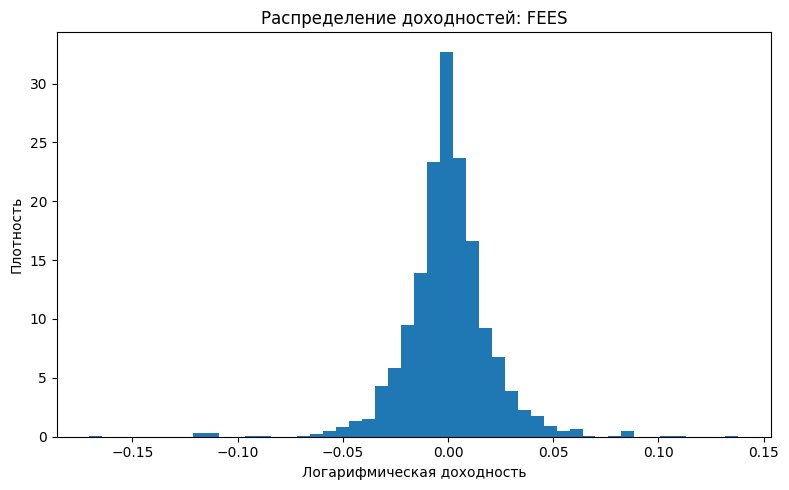

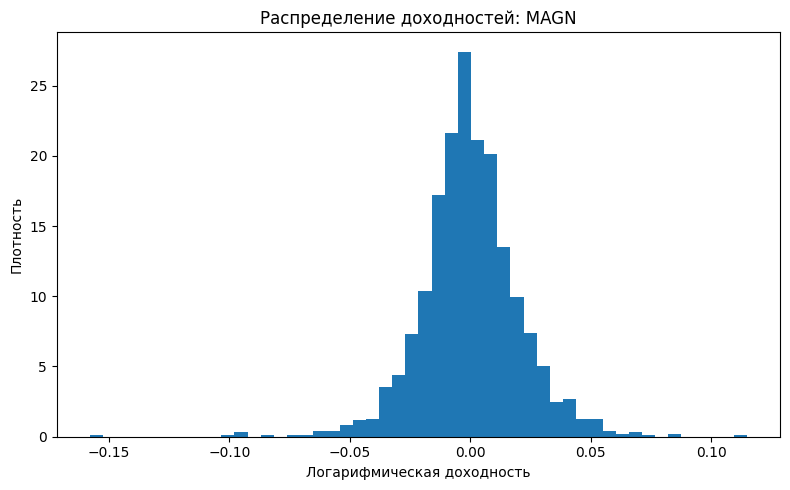

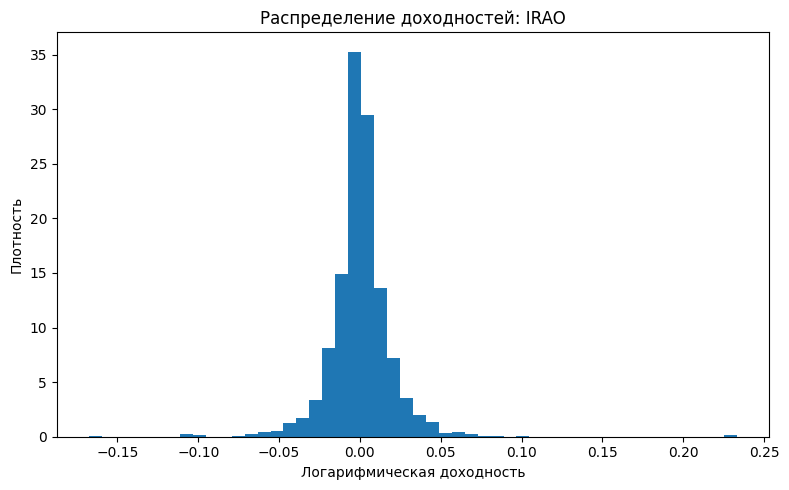

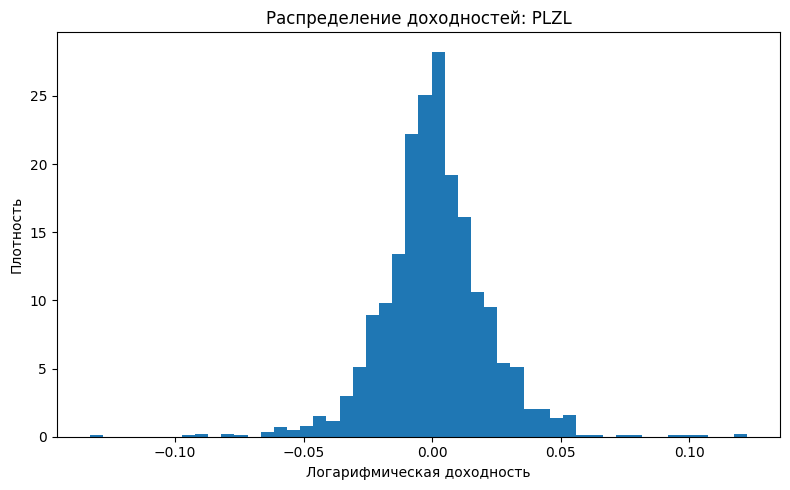

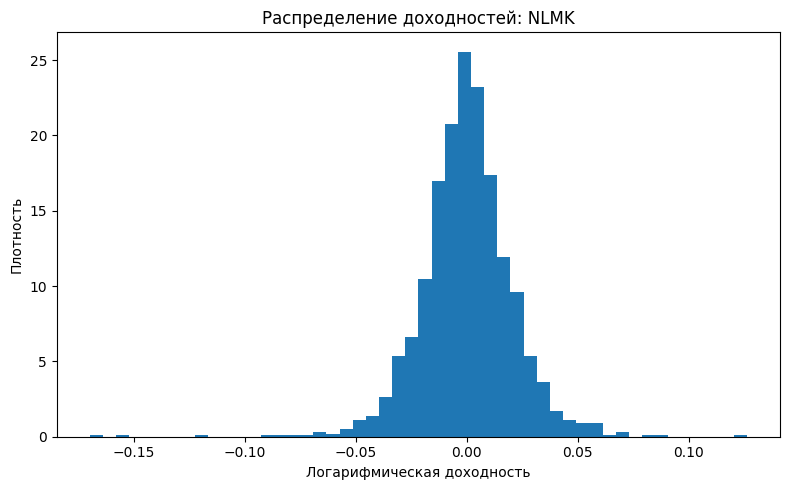

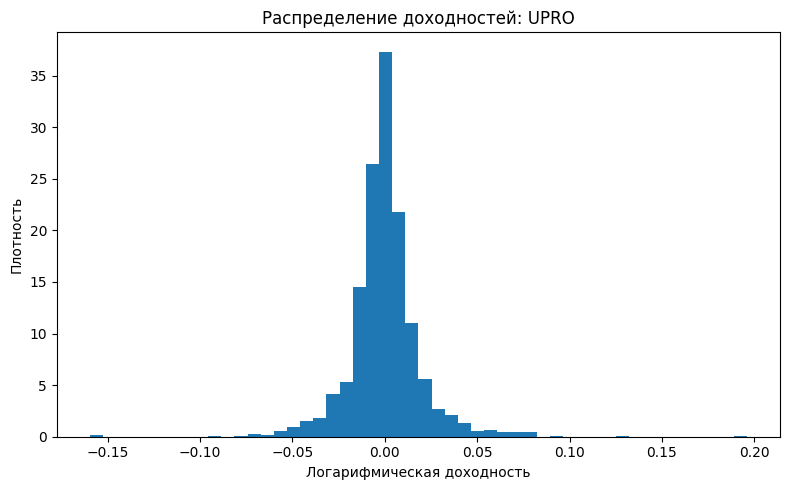

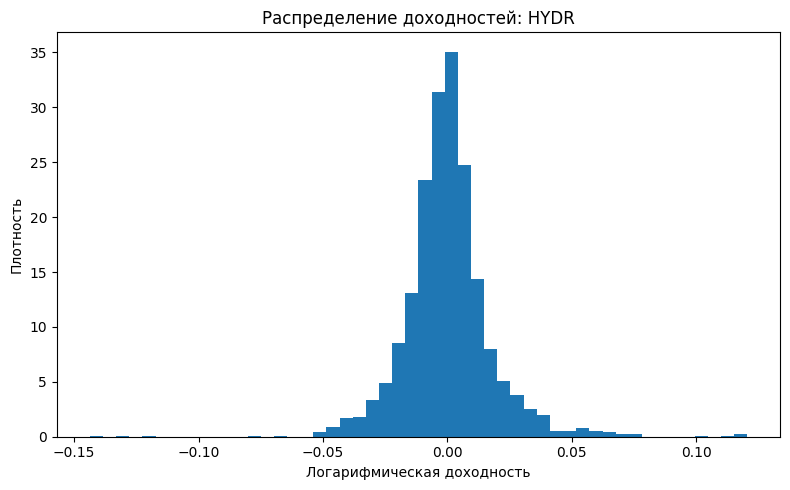

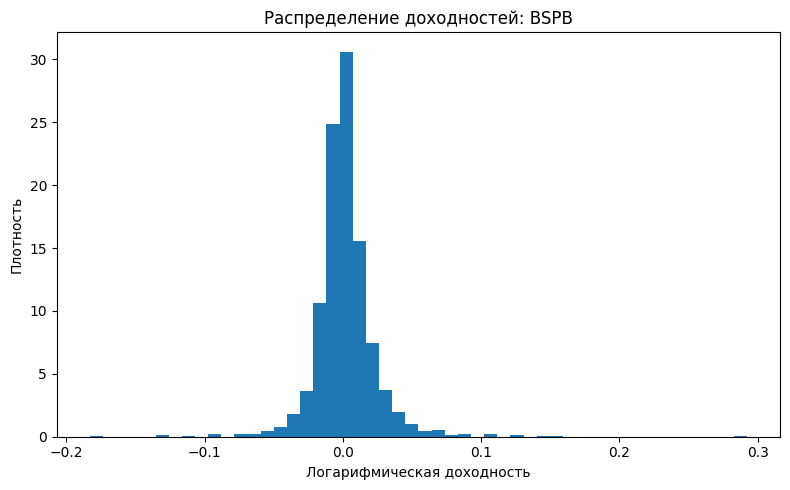

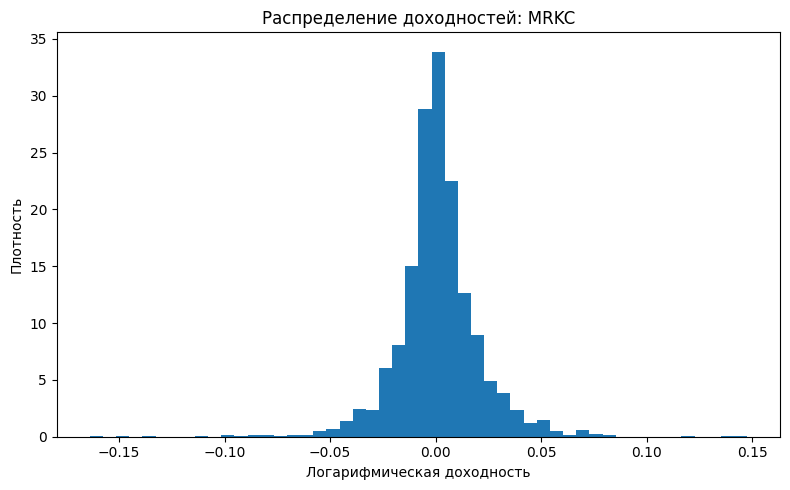

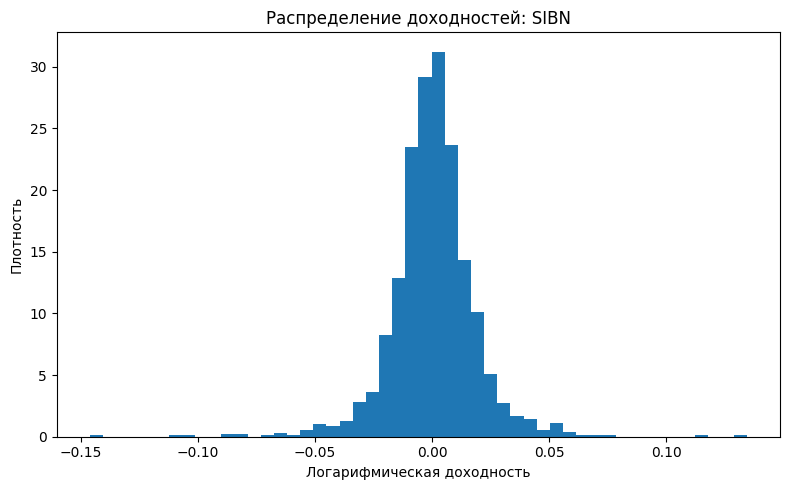

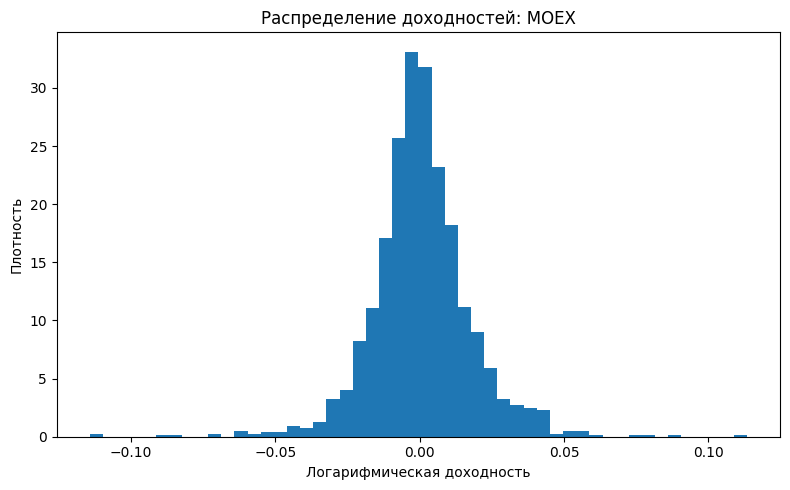

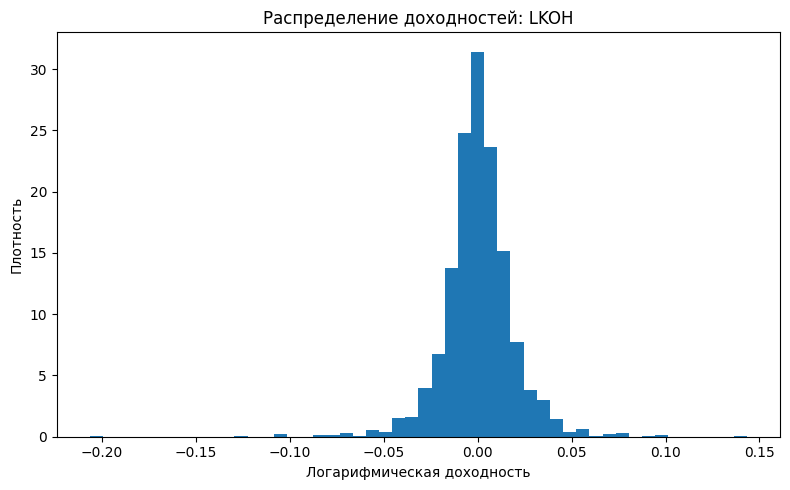

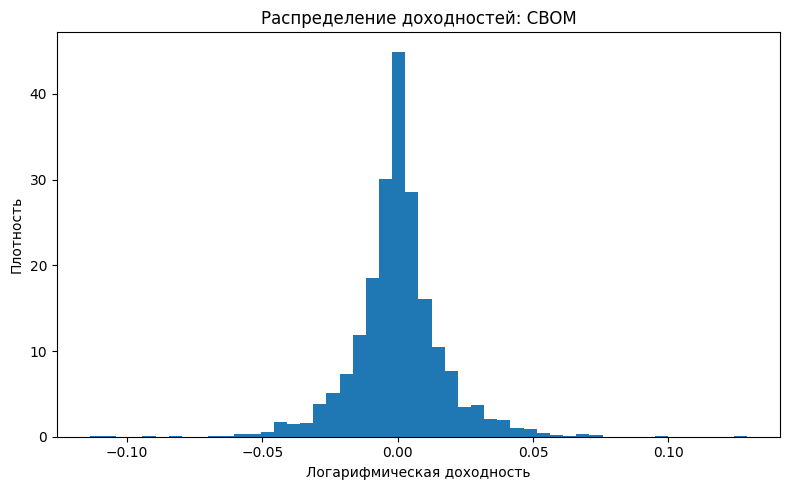

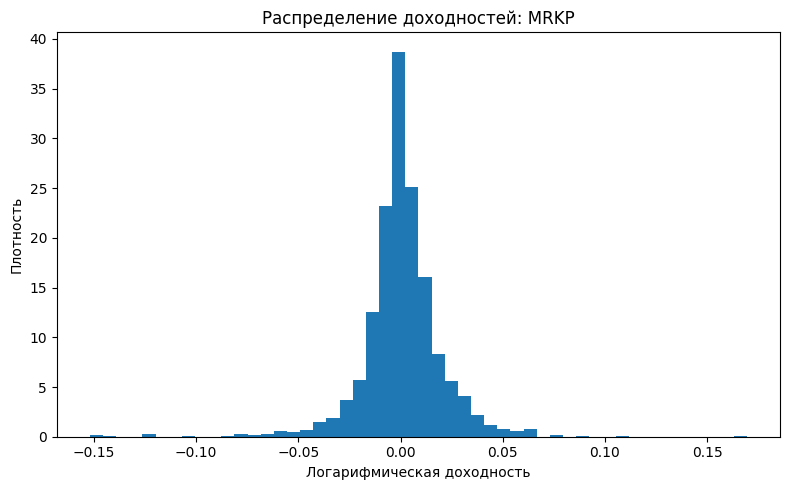

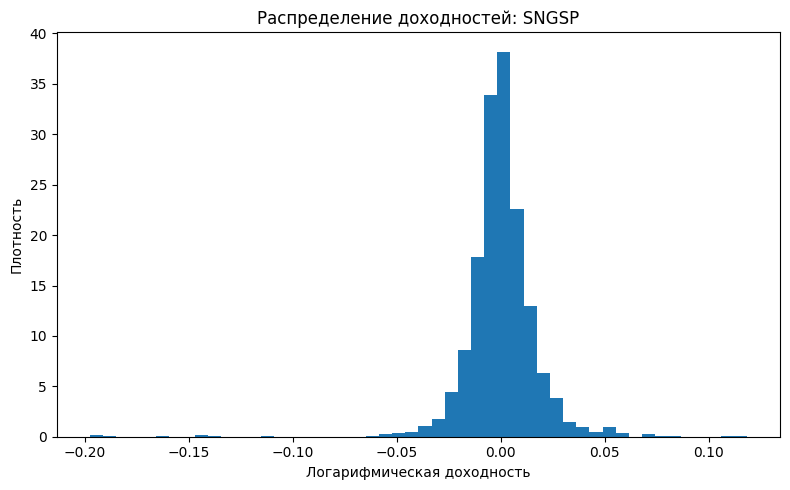

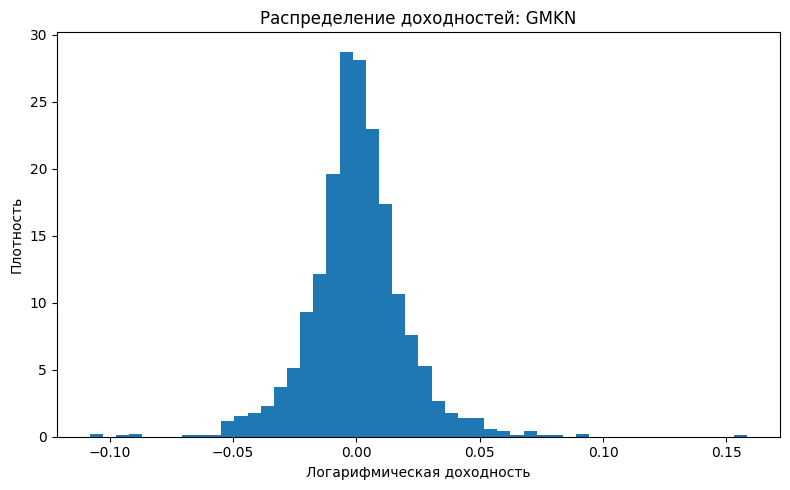

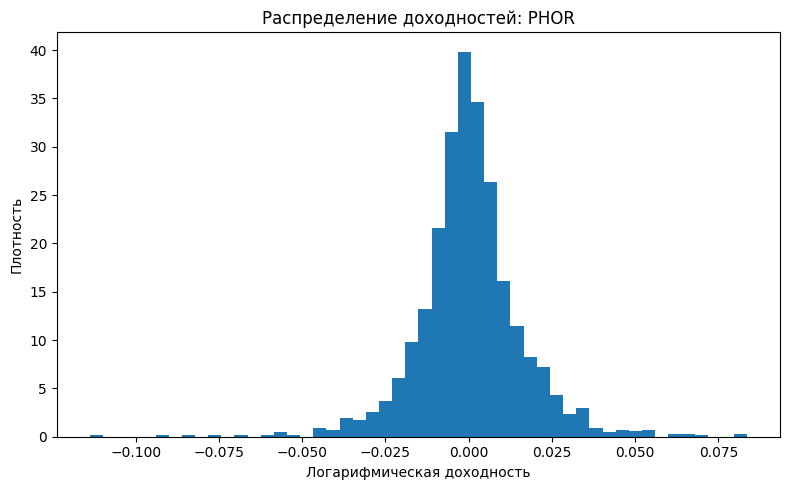

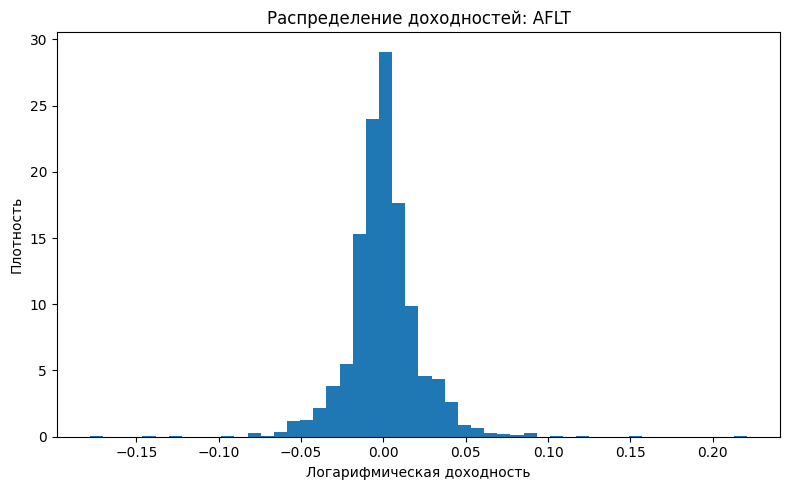

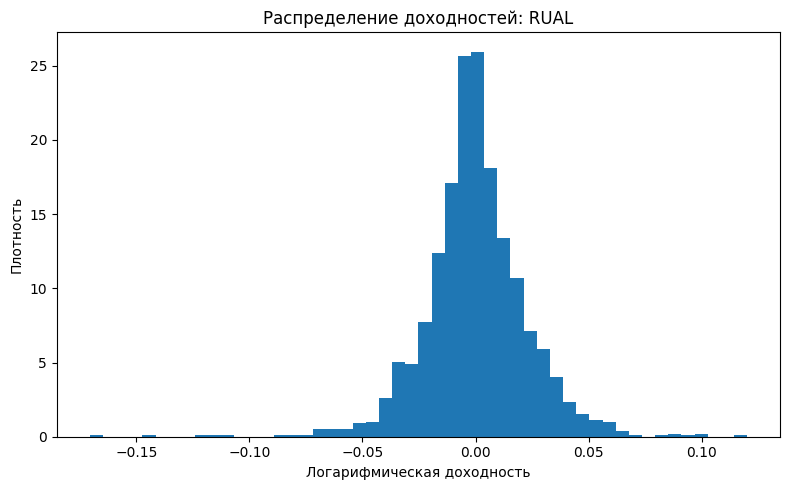

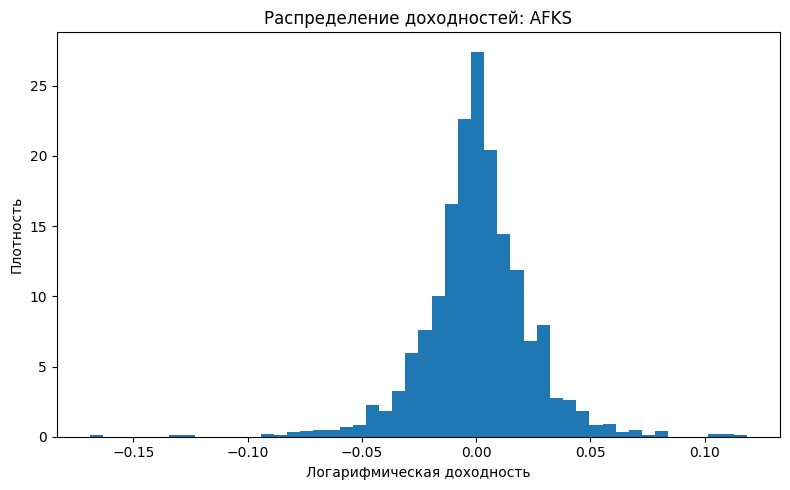

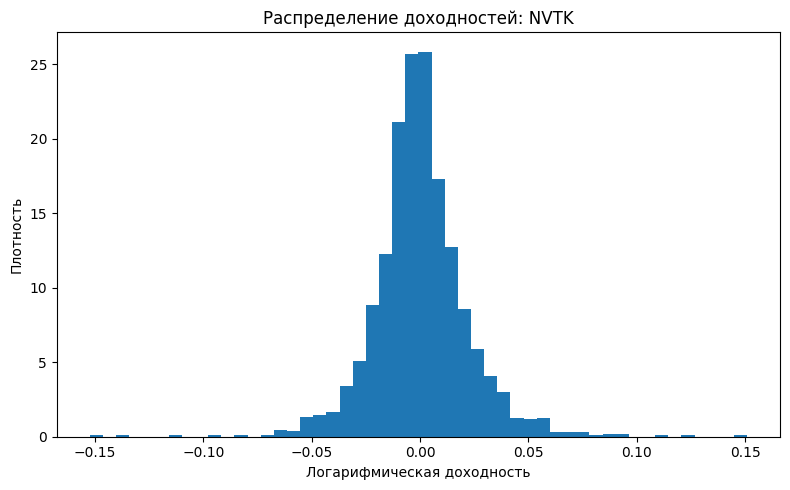

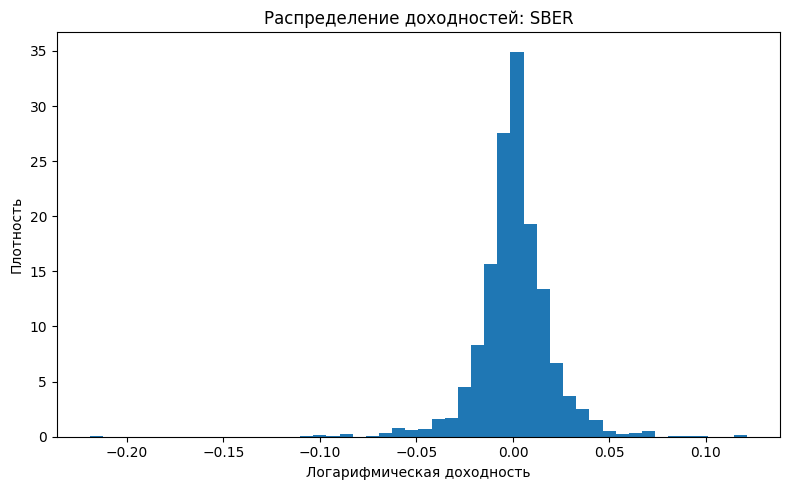

In [ ]:
import numpy as np

for col in returns.columns:
    plt.figure(figsize=(8,5))
    plt.hist(returns[col], bins=50, density=True)
    plt.title(f"Распределение доходностей: {col}")
    plt.xlabel("Логарифмическая доходность")
    plt.ylabel("Плотность")
    plt.tight_layout()
    plt.show()


In [ ]:
print(returns.index.min())
print(returns.index.max())
print("Размер матрицы:", returns.shape)


2019-01-04 00:00:00
2025-12-30 00:00:00
Размер матрицы: (1710, 33)


In [ ]:
print("Минимальная волатильность:", returns.std().min())
print("Максимальная волатильность:", returns.std().max())
print("Средняя волатильность:", returns.std().mean())

print("Минимальная асимметрия:", returns.skew().min())
print("Максимальная асимметрия:", returns.skew().max())

print("Минимальный эксцесс:", returns.kurtosis().min())
print("Максимальный эксцесс:", returns.kurtosis().max())

corr = returns.corr()
mean_corr = corr.where(~np.eye(corr.shape[0], dtype=bool)).mean().mean()
corr_values = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack()

print("Средняя корреляция:", mean_corr)
print("Максимальная корреляция:", corr_values.max())
print("Минимальная корреляция:", corr_values.min())


Минимальная волатильность: 0.015843914610783376
Максимальная волатильность: 0.024599986258669736
Средняя волатильность: 0.020512532742259917
Минимальная асимметрия: -2.6426246900483656
Максимальная асимметрия: 1.3799914274241818
Минимальный эксцесс: 4.020275884492774
Максимальный эксцесс: 50.991315227599415
Средняя корреляция: 0.40863430770214054
Максимальная корреляция: 0.7686497512219046
Минимальная корреляция: 0.1525107119249407


Акции для scatter plot: ['ROSN', 'SBER', 'AFKS', 'TATN', 'NLMK']


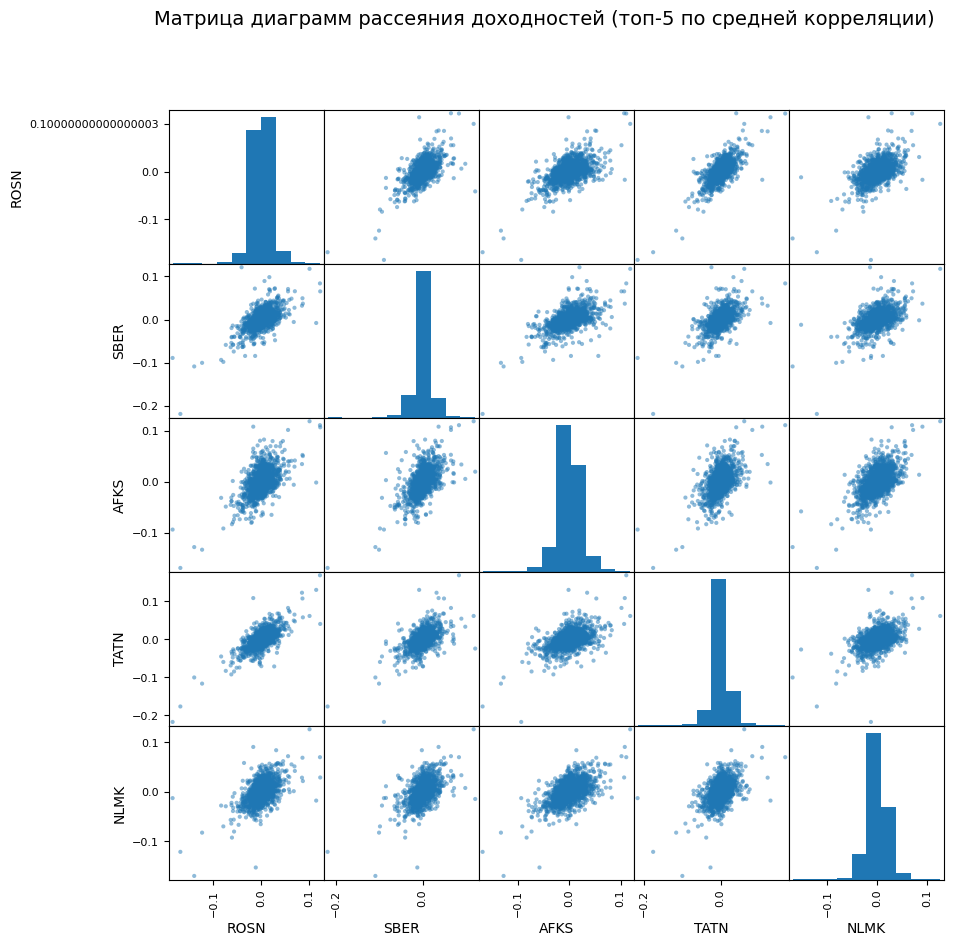

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Предполагаем, что у тебя есть DataFrame returns (1710 × 33)

# 1. Считаем корреляционную матрицу
corr_matrix = returns.corr()

# 2. Вычисляем среднюю корреляцию для каждой акции
mean_corr = corr_matrix.mean().sort_values(ascending=False)

# 3. Берём топ-5 наиболее коррелированных акций
top5 = mean_corr.index[:5]

print("Акции для scatter plot:", list(top5))

# 4. Строим матрицу диаграмм рассеяния
pd.plotting.scatter_matrix(
    returns[top5],
    figsize=(10, 10),
    diagonal='hist',
    alpha=0.5
)

plt.suptitle("Матрица диаграмм рассеяния доходностей (топ-5 по средней корреляции)", fontsize=14)
plt.show()


PCA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Стандартизация
scaler = StandardScaler()
returns_std = scaler.fit_transform(returns)

print("Размер стандартизированной матрицы:", returns_std.shape)

Размер стандартизированной матрицы: (1710, 33)


In [ ]:
pca = PCA()
pca.fit(returns_std)

# Собственные значения
eigenvalues = pca.explained_variance_

# Доля объяснённой дисперсии
explained_variance_ratio = pca.explained_variance_ratio_

# Кумулятивная доля
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Первые 5 собственных значений:")
print(eigenvalues[:5])

print("\nПервые 5 долей объяснённой дисперсии:")
print(explained_variance_ratio[:5])

Первые 5 собственных значений:
[14.4189003   1.37859215  1.18812994  1.11899038  1.00029044]

Первые 5 долей объяснённой дисперсии:
[0.43668085 0.04175109 0.03598288 0.03388897 0.03029411]


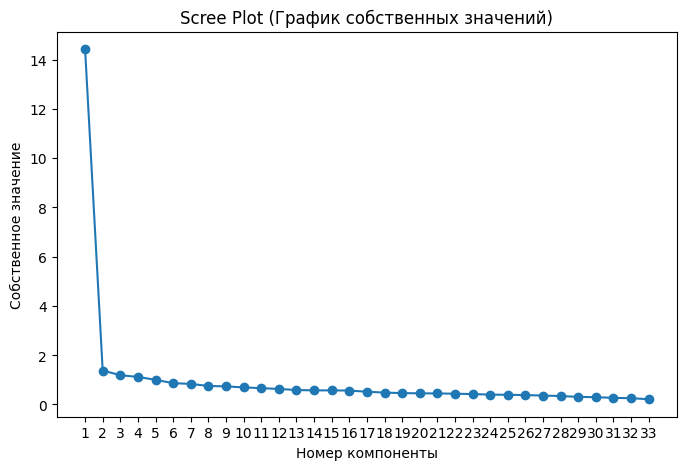

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title("Scree Plot (График собственных значений)")
plt.xlabel("Номер компоненты")
plt.ylabel("Собственное значение")
plt.xticks(range(1, len(eigenvalues)+1))
plt.show()

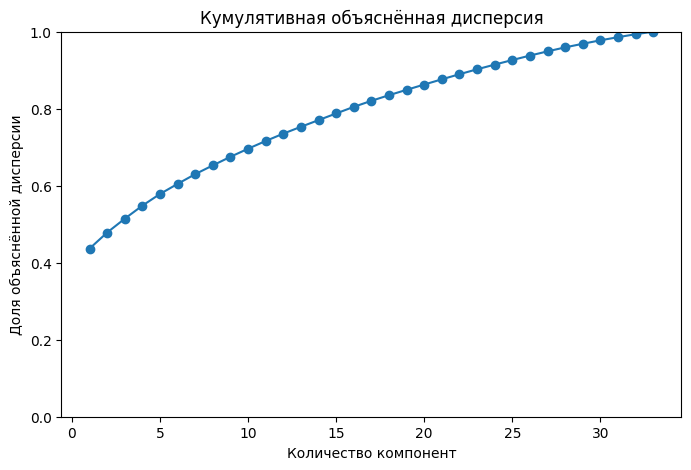

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Кумулятивная объяснённая дисперсия")
plt.xlabel("Количество компонент")
plt.ylabel("Доля объяснённой дисперсии")
plt.ylim(0,1)
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(returns.columns))],
    index=returns.columns
)

# Нагрузки первой компоненты
pc1_loadings = loadings['PC1'].sort_values(ascending=False)

print("Нагрузки первой главной компоненты:")
print(pc1_loadings)

Нагрузки первой главной компоненты:
ROSN     0.211721
SBER     0.204072
AFKS     0.198591
TATN     0.198181
VTBR     0.196557
NLMK     0.196211
NVTK     0.192270
FEES     0.190430
MAGN     0.190022
AFLT     0.189568
ALRS     0.189471
SIBN     0.187333
GMKN     0.187068
CHMF     0.186699
SNGS     0.184841
IRAO     0.184811
LKOH     0.184384
HYDR     0.178092
RUAL     0.177057
GAZP     0.176262
MOEX     0.174376
UPRO     0.168939
MTSS     0.168037
CBOM     0.164916
TRNFP    0.156833
PIKK     0.149985
MRKC     0.141650
MRKP     0.139518
LSRG     0.138808
BSPB     0.132392
SNGSP    0.123183
PHOR     0.105903
PLZL     0.104507
Name: PC1, dtype: float64


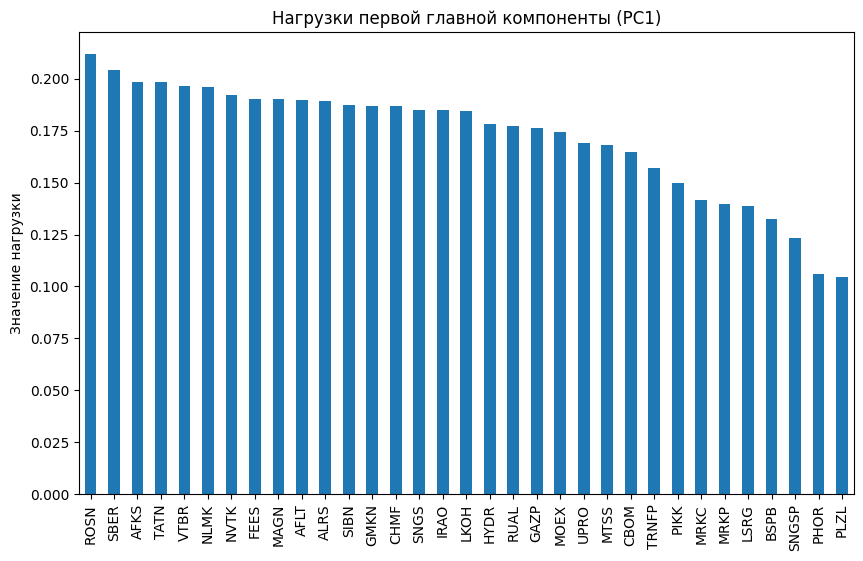

In [ ]:
plt.figure(figsize=(10,6))
pc1_loadings.plot(kind='bar')
plt.title("Нагрузки первой главной компоненты (PC1)")
plt.ylabel("Значение нагрузки")
plt.xticks(rotation=90)
plt.show()

In [ ]:
pc2_loadings = loadings['PC2'].sort_values(ascending=False)
pc3_loadings = loadings['PC3'].sort_values(ascending=False)

print("Нагрузки PC2:")
print(pc2_loadings)

print("\nНагрузки PC3:")
print(pc3_loadings)

Нагрузки PC2:
MRKC     0.396090
MRKP     0.392535
IRAO     0.222762
BSPB     0.210673
LSRG     0.191511
SIBN     0.148373
TATN     0.118379
LKOH     0.112345
FEES     0.110253
ROSN     0.093041
TRNFP    0.085750
MTSS     0.079372
UPRO     0.053487
HYDR     0.052781
SNGS     0.036592
AFLT     0.020380
GAZP     0.017469
SBER     0.000461
VTBR    -0.011493
CBOM    -0.036907
MOEX    -0.047455
PLZL    -0.078269
NVTK    -0.081855
SNGSP   -0.083915
AFKS    -0.104431
ALRS    -0.107565
PIKK    -0.158744
RUAL    -0.170319
GMKN    -0.177769
PHOR    -0.254635
NLMK    -0.293191
MAGN    -0.299374
CHMF    -0.308546
Name: PC2, dtype: float64

Нагрузки PC3:
LKOH     0.353646
TATN     0.332963
ROSN     0.242589
SIBN     0.238502
GAZP     0.228267
NVTK     0.200033
SNGS     0.141512
SBER     0.119478
PHOR     0.055489
VTBR     0.046094
ALRS     0.044341
GMKN     0.027919
CBOM     0.023963
TRNFP    0.014020
SNGSP   -0.004311
IRAO    -0.004606
RUAL    -0.013132
AFLT    -0.030390
AFKS    -0.035238
MOEX    -

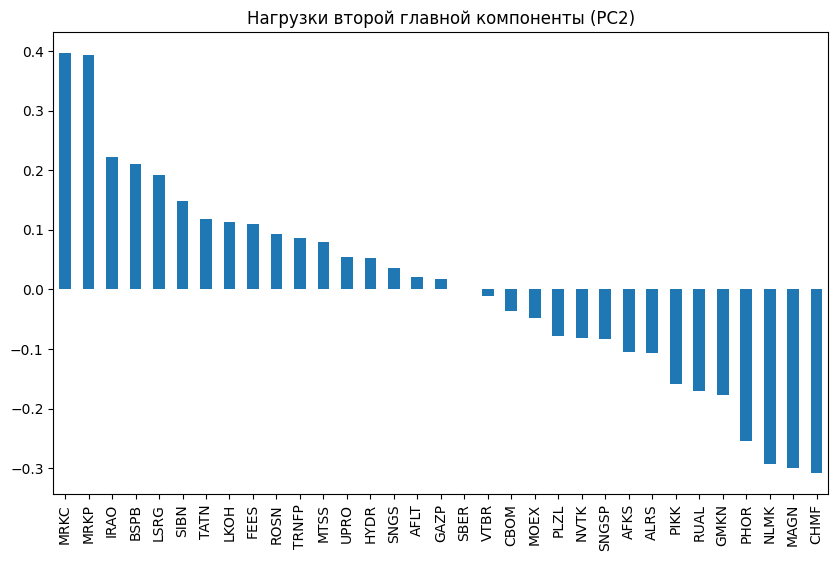

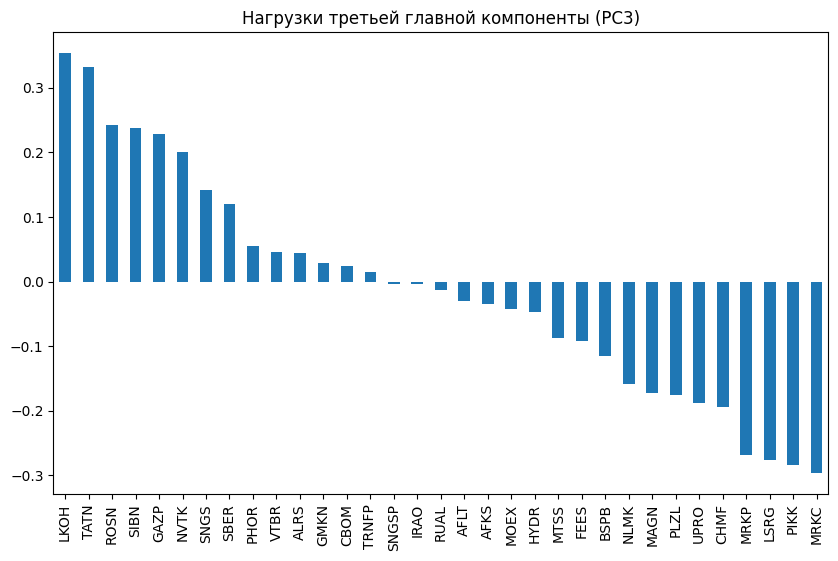

In [ ]:
plt.figure(figsize=(10,6))
pc2_loadings.plot(kind='bar')
plt.title("Нагрузки второй главной компоненты (PC2)")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10,6))
pc3_loadings.plot(kind='bar')
plt.title("Нагрузки третьей главной компоненты (PC3)")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Получаем значения главных компонент (факторные временные ряды)
pc_scores = pca.transform(returns_std)

pc_df = pd.DataFrame(
    pc_scores,
    columns=[f'PC{i+1}' for i in range(returns.shape[1])],
    index=returns.index
)

# Извлекаем доходности индекса Мосбиржи из ваших данных
imoex_returns = returns['MOEX']

# Корреляция PC1 с индексом
correlation_with_index = pc_df['PC1'].corr(imoex_returns)

print("Корреляция PC1 с индексом Мосбиржи:", correlation_with_index)

Корреляция PC1 с индексом Мосбиржи: 0.6619499349842419


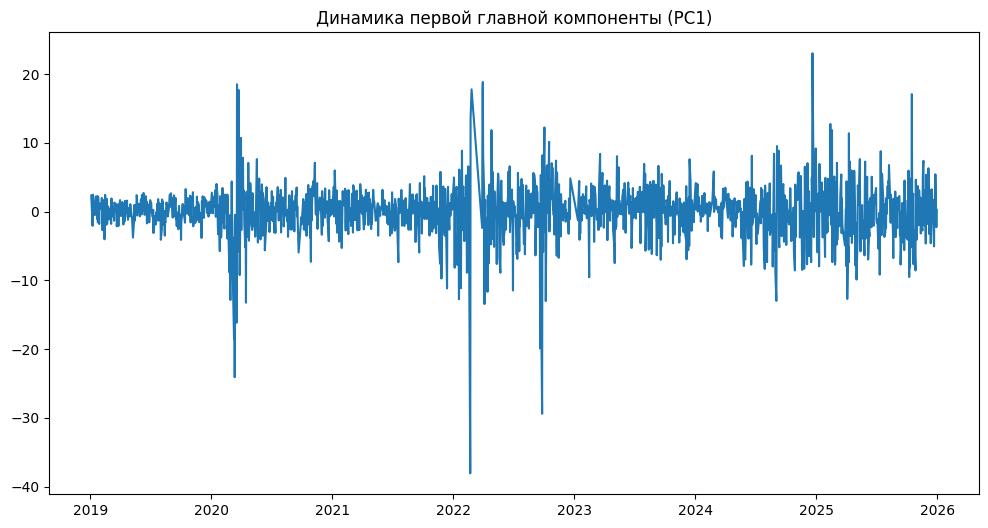

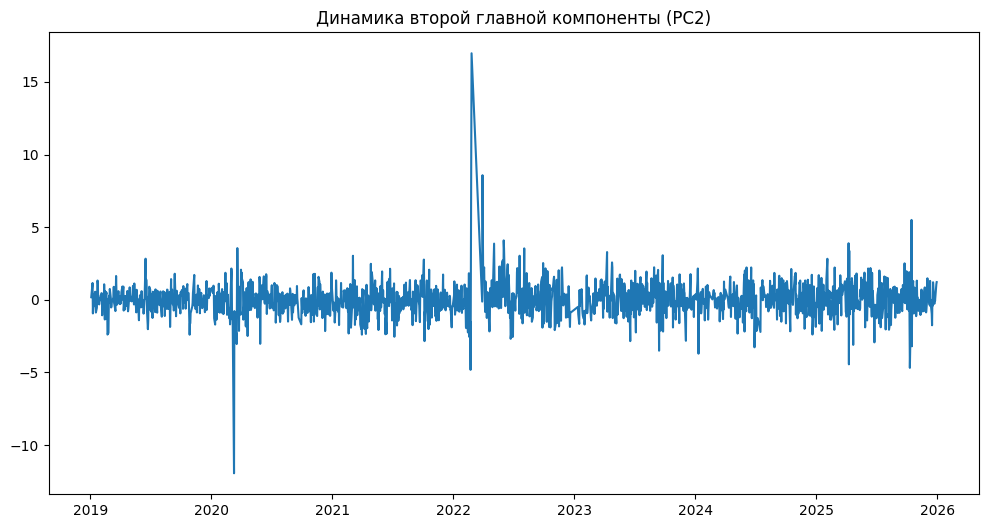

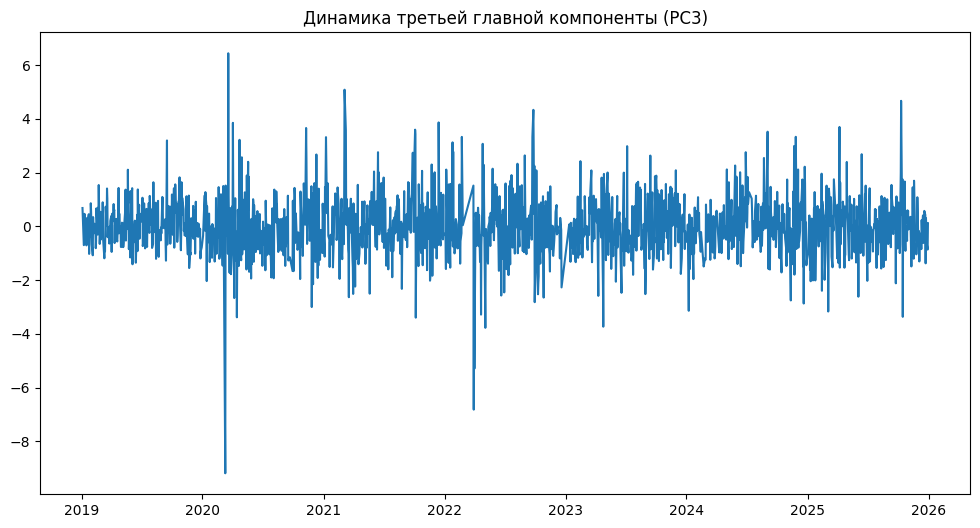

In [ ]:
# Уже есть pc_df

plt.figure(figsize=(12,6))
plt.plot(pc_df['PC1'])
plt.title("Динамика первой главной компоненты (PC1)")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(pc_df['PC2'])
plt.title("Динамика второй главной компоненты (PC2)")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(pc_df['PC3'])
plt.title("Динамика третьей главной компоненты (PC3)")
plt.show()

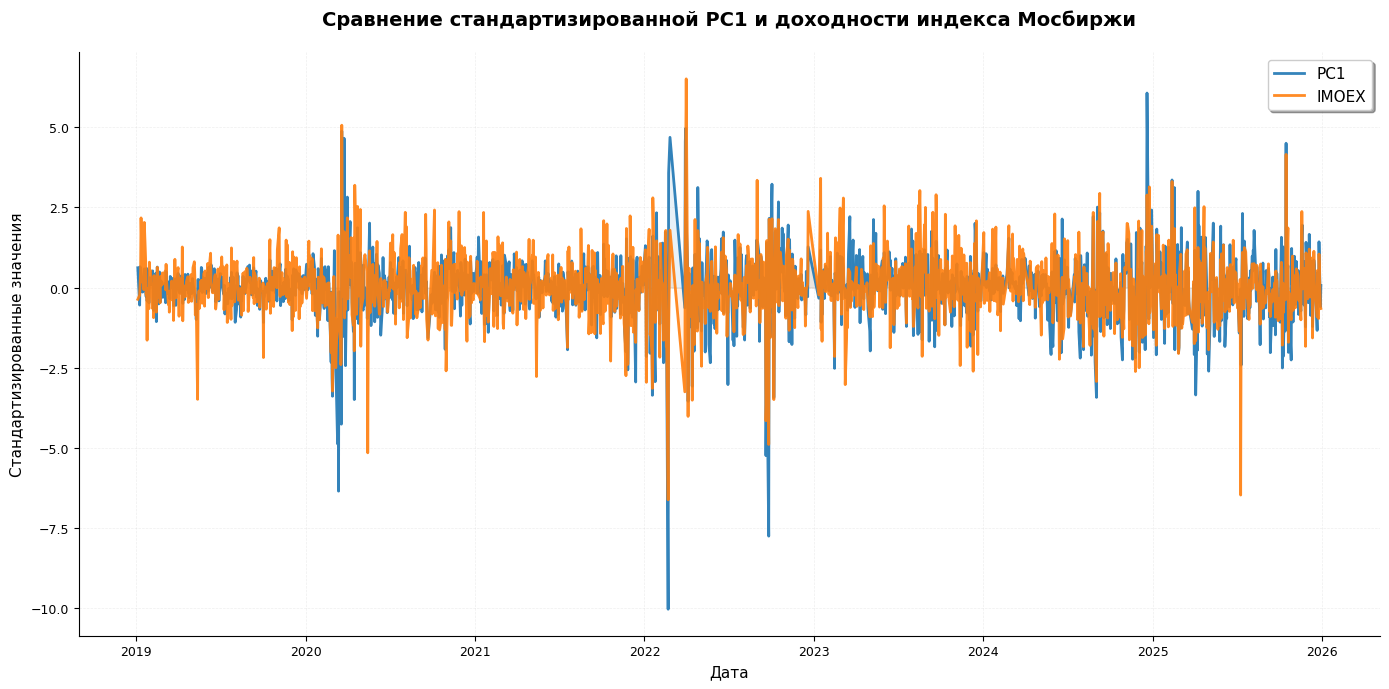


Альтернативный вариант с более контрастными цветами:


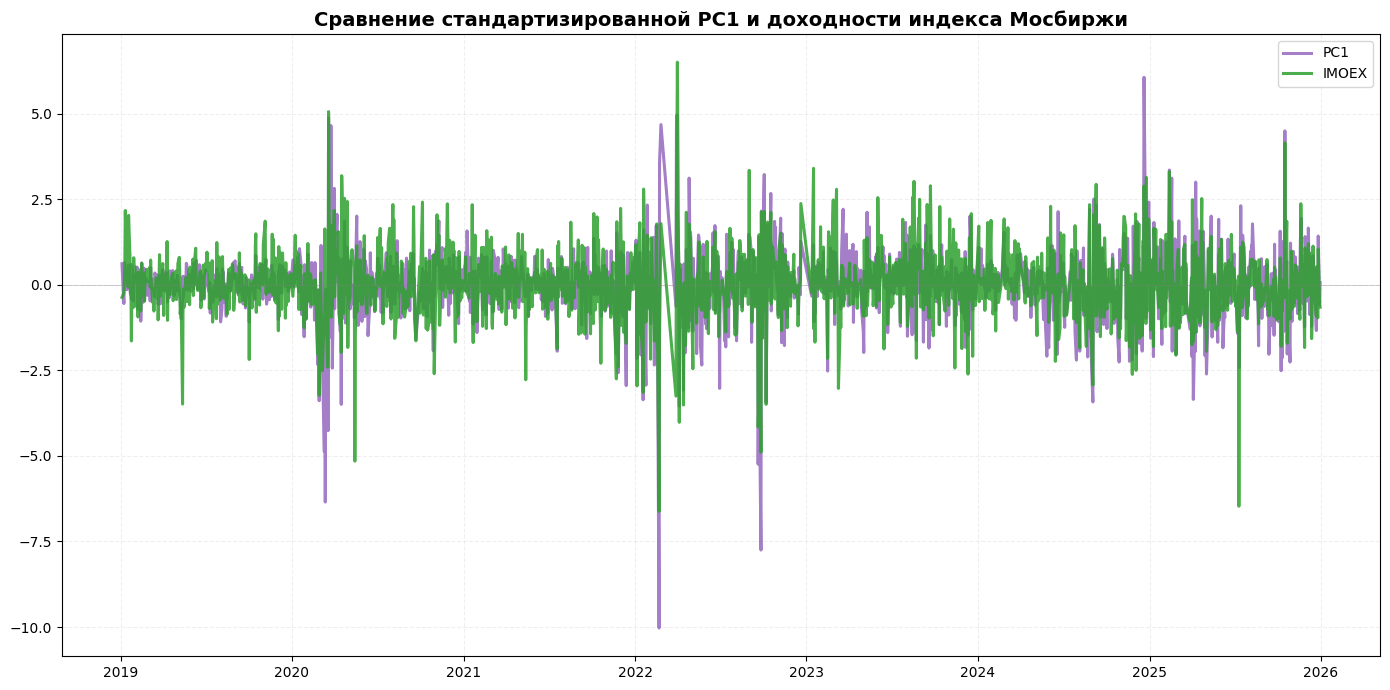

Корреляция между PC1 и IMOEX: 0.6619


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Объединяем в один DataFrame
comparison_df = pd.DataFrame({
    'PC1': pc_df['PC1'],
    'IMOEX': imoex_returns
}).dropna()

# Стандартизация
scaler = StandardScaler()
scaled_values = scaler.fit_transform(comparison_df)

scaled_df = pd.DataFrame(
    scaled_values,
    index=comparison_df.index,
    columns=['PC1 (std)', 'IMOEX (std)']
)

# График с улучшенными цветами
plt.figure(figsize=(14, 7))

# Используем более приятную цветовую палитру
# Тёмно-синий для PC1 и тёплый оранжево-красный для IMOEX
plt.plot(scaled_df['PC1 (std)'],
         color='#1f77b4',  # приятный синий
         linewidth=2.0,
         alpha=0.9,
         label='PC1')

plt.plot(scaled_df['IMOEX (std)'],
         color='#ff7f0e',  # тёплый оранжевый
         linewidth=2.0,
         alpha=0.9,
         label='IMOEX')

# Добавляем лёгкую заливку под кривыми для лучшего восприятия
plt.fill_between(scaled_df.index,
                 scaled_df['PC1 (std)'],
                 0,
                 color='#1f77b4',
                 alpha=0.1)

plt.fill_between(scaled_df.index,
                 scaled_df['IMOEX (std)'],
                 0,
                 color='#ff7f0e',
                 alpha=0.1)

plt.title("Сравнение стандартизированной PC1 и доходности индекса Мосбиржи",
          fontsize=14,
          fontweight='bold',
          pad=20)

plt.legend(loc='upper right',
          frameon=True,
          fancybox=True,
          shadow=True,
          fontsize=11)

plt.grid(True,
         alpha=0.2,
         linestyle='--',
         linewidth=0.5)

# Добавляем подписи осей
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Стандартизированные значения', fontsize=11)

# Делаем тики на осях более читаемыми
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# Убираем верхнюю и правую границы для более чистого вида
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Альтернативный вариант с другой цветовой схемой (более контрастной)
print("\n" + "="*60)
print("Альтернативный вариант с более контрастными цветами:")
print("="*60)

plt.figure(figsize=(14, 7))

# Фиолетовый для PC1 и зелёный для IMOEX
plt.plot(scaled_df['PC1 (std)'],
         color='#9467bd',  # фиолетовый
         linewidth=2.2,
         alpha=0.85,
         label='PC1')

plt.plot(scaled_df['IMOEX (std)'],
         color='#2ca02c',  # зелёный
         linewidth=2.2,
         alpha=0.85,
         label='IMOEX')

plt.title("Сравнение стандартизированной PC1 и доходности индекса Мосбиржи",
          fontsize=14,
          fontweight='bold')

plt.legend(loc='upper right', frameon=True)
plt.grid(alpha=0.2, linestyle='--')

# Добавляем горизонтальную линию на уровне 0 для ориентации
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# Рассчитываем корреляцию для информации
correlation = scaled_df['PC1 (std)'].corr(scaled_df['IMOEX (std)'])
print(f"Корреляция между PC1 и IMOEX: {correlation:.4f}")

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Берем первые три компоненты
factors = pc_df[['PC1', 'PC2', 'PC3']]

# Добавляем константу
X = sm.add_constant(factors)

results = {}

for stock in returns.columns:
    y = returns[stock].loc[X.index]

    model = sm.OLS(y, X).fit()

    results[stock] = {
        'alpha': model.params['const'],
        'beta_PC1': model.params['PC1'],
        'beta_PC2': model.params['PC2'],
        'beta_PC3': model.params['PC3'],
        'R2': model.rsquared
    }

regression_df = pd.DataFrame(results).T

regression_df.sort_values('R2', ascending=False).head()

,alpha,beta_PC1,beta_PC2,beta_PC3,R2
ROSN,0.000235,0.004242,0.001864,0.004860,0.727769
TATN,0.000095,0.004327,0.002585,0.007270,0.716935
NLMK,0.000050,0.004068,-0.006079,-0.003290,0.703124
MAGN,0.000023,0.003907,-0.006155,-0.003556,0.679341
CHMF,0.000414,0.003809,-0.006295,-0.003979,0.678643


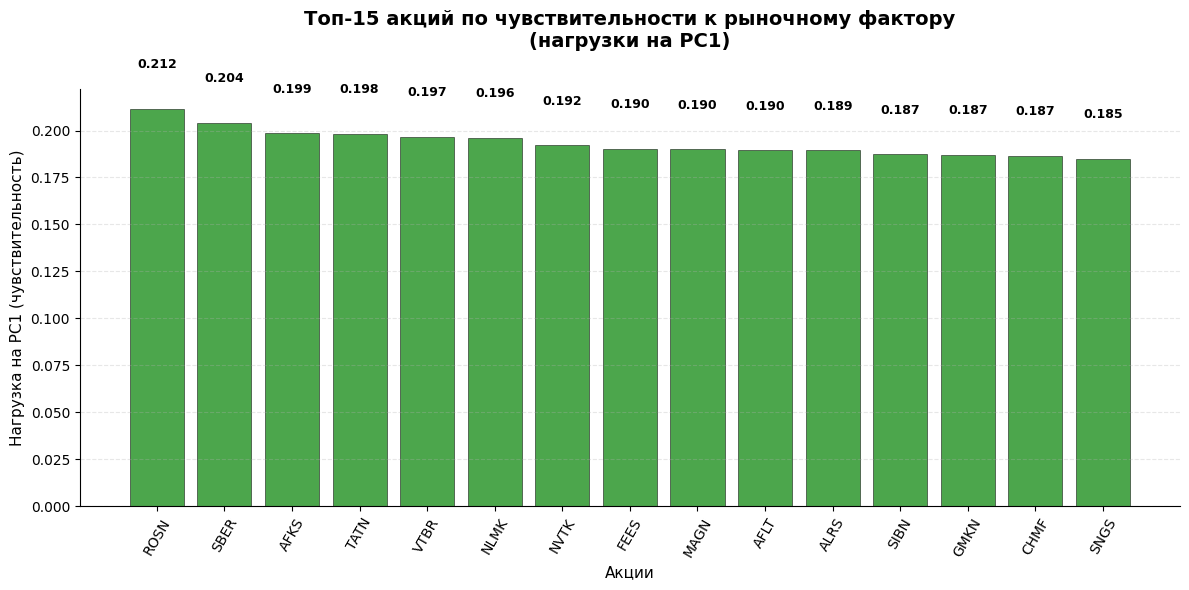

ТОП-15 АКЦИЙ ПО ЧУВСТВИТЕЛЬНОСТИ К РЫНОЧНОМУ ФАКТОРУ:
ticker  loading_PC1
  ROSN     0.211721
  SBER     0.204072
  AFKS     0.198591
  TATN     0.198181
  VTBR     0.196557
  NLMK     0.196211
  NVTK     0.192270
  FEES     0.190430
  MAGN     0.190022
  AFLT     0.189568
  ALRS     0.189471
  SIBN     0.187333
  GMKN     0.187068
  CHMF     0.186699
  SNGS     0.184841

Доля дисперсии, объясняемая PC1: 43.67%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Используем существующий pca объект
# Веса первой главной компоненты (нагрузки)
loadings = pca.components_[0]  # вектор весов для PC1

# Создаем DataFrame с нагрузками
loadings_df = pd.DataFrame({
    'ticker': returns.columns,
    'loading_PC1': loadings,
    'abs_loading': np.abs(loadings)  # для сортировки по модулю
})

# Сортируем по модулю нагрузки (чувствительности)
loadings_sorted = loadings_df.sort_values('abs_loading', ascending=False)
top_loadings = loadings_sorted.head(15)

# Визуализация
plt.figure(figsize=(12, 6))

# Разные цвета для положительных и отрицательных нагрузок
colors = ['green' if x > 0 else 'red' for x in top_loadings['loading_PC1']]

bars = plt.bar(range(len(top_loadings)),
               top_loadings['loading_PC1'].values,
               color=colors,
               alpha=0.7,
               edgecolor='black',
               linewidth=0.5)

# Настраиваем подписи осей
plt.xticks(range(len(top_loadings)), top_loadings['ticker'].values,
           rotation=60, fontsize=10)
plt.ylabel('Нагрузка на PC1 (чувствительность)', fontsize=11)
plt.xlabel('Акции', fontsize=11)

# Добавляем значения над столбцами с отступом
for i, (bar, val) in enumerate(zip(bars, top_loadings['loading_PC1'].values)):
    offset = 0.02 if val > 0 else -0.04
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + offset,
             f'{val:.3f}',
             ha='center',
             va='bottom' if val > 0 else 'top',
             fontsize=9,
             fontweight='bold')

plt.title('Топ-15 акций по чувствительности к рыночному фактору\n(нагрузки на PC1)',
          fontsize=14, fontweight='bold', pad=30)  # увеличен отступ

# Добавляем горизонтальную линию на уровне 0
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

plt.grid(axis='y', alpha=0.3, linestyle='--')

# Убираем верхнюю и правую границы
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Выводим информацию
print("="*60)
print("ТОП-15 АКЦИЙ ПО ЧУВСТВИТЕЛЬНОСТИ К РЫНОЧНОМУ ФАКТОРУ:")
print("="*60)
print(top_loadings[['ticker', 'loading_PC1']].to_string(index=False))

print(f"\nДоля дисперсии, объясняемая PC1: {pca.explained_variance_ratio_[0]:.2%}")

In [ ]:
# Создаем лаг PC1
pc_df['PC1_lag'] = pc_df['PC1'].shift(1)

# Совмещаем с индексом
predict_df = pd.DataFrame({
    'Index_Return': imoex_returns,
    'PC1_lag': pc_df['PC1_lag']
}).dropna()

import statsmodels.api as sm

X_pred = sm.add_constant(predict_df['PC1_lag'])
y_pred = predict_df['Index_Return']

model_pred = sm.OLS(y_pred, X_pred).fit()

print(model_pred.summary())

                            OLS Regression Results                            
Dep. Variable:           Index_Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.381
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.123
Time:                        11:47:39   Log-Likelihood:                 4504.3
No. Observations:                1709   AIC:                            -9005.
Df Residuals:                    1707   BIC:                            -8994.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.331      0.1

**глава 3**


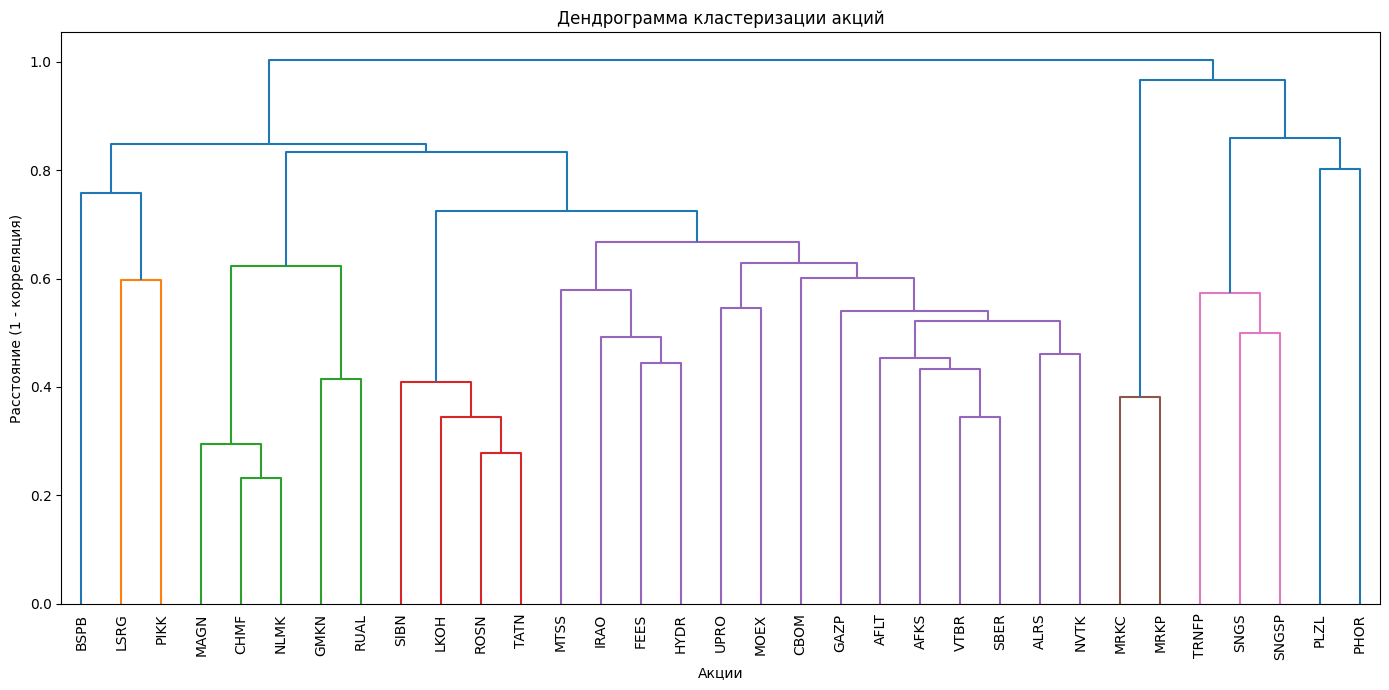

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Корреляционная матрица
corr_matrix = returns.corr()

# 2. Перевод корреляции в расстояние
distance_matrix = 1 - corr_matrix

# 3. Преобразование в "сжатый" формат (обязательно!)
from scipy.spatial.distance import squareform
condensed_distance = squareform(distance_matrix.values)

# 4. Иерархическая кластеризация
Z = linkage(condensed_distance, method='ward')

# 5. Построение дендрограммы
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    labels=returns.columns,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Дендрограмма кластеризации акций')
plt.xlabel('Акции')
plt.ylabel('Расстояние (1 - корреляция)')

plt.tight_layout()
plt.show()

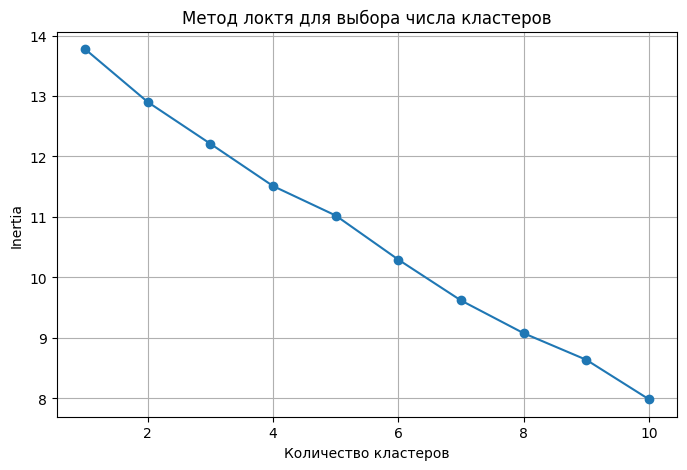

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(returns.T)  # транспонируем!
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Метод локтя для выбора числа кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')

plt.grid()
plt.show()

In [ ]:
k = 4  # поменяешь после графика

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(returns.T)

cluster_df = pd.DataFrame({
    'Ticker': returns.columns,
    'Cluster': clusters
})

print(cluster_df.sort_values('Cluster'))

   Ticker  Cluster
0    SNGS        0
1    GAZP        0
3    VTBR        0
4    MTSS        0
7   TRNFP        0
5    LSRG        0
10   TATN        0
8    ROSN        0
14   PLZL        0
13   IRAO        0
11   FEES        0
22   LKOH        0
20   SIBN        0
18   BSPB        0
17   HYDR        0
16   UPRO        0
31   NVTK        0
27   PHOR        0
28   AFLT        0
25  SNGSP        0
23   CBOM        0
21   MOEX        0
32   SBER        0
9    PIKK        1
15   NLMK        2
12   MAGN        2
2    ALRS        2
29   RUAL        2
30   AFKS        2
26   GMKN        2
6    CHMF        2
19   MRKC        3
24   MRKP        3


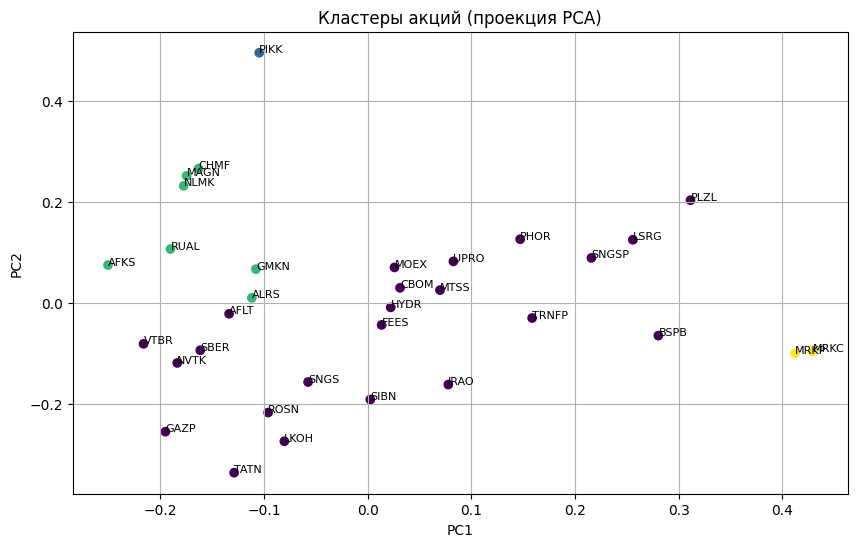

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(returns.T)

plt.figure(figsize=(10, 6))

plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=clusters
)

for i, ticker in enumerate(returns.columns):
    plt.text(reduced[i, 0], reduced[i, 1], ticker, fontsize=8)

plt.title('Кластеры акций (проекция PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid()
plt.show()